In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import xgboost as xgb
except:
    %pip install -q xgboost
    import xgboost as xgb

In [2]:
!pip show xgboost

Name: xgboost
Version: 3.1.3
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: TPOT


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

import warnings

2026-03-16 02:57:40.224051: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773629860.520627      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773629860.600008      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773629861.257351      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773629861.257470      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773629861.257474      17 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']] 
BASE   = NUMS + CATS

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total Features: {len(BASE)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16
Total Features: 19


In [7]:
display(train.head())
train.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [8]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [9]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057,0.225208
std,0.317936,25.061922,31.067444,2353.916710,0.417719
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,12.000000,29.900000,639.650000,0.000000
50%,0.000000,35.000000,74.100000,1433.650000,0.000000
75%,0.000000,62.000000,90.800000,4263.800000,0.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


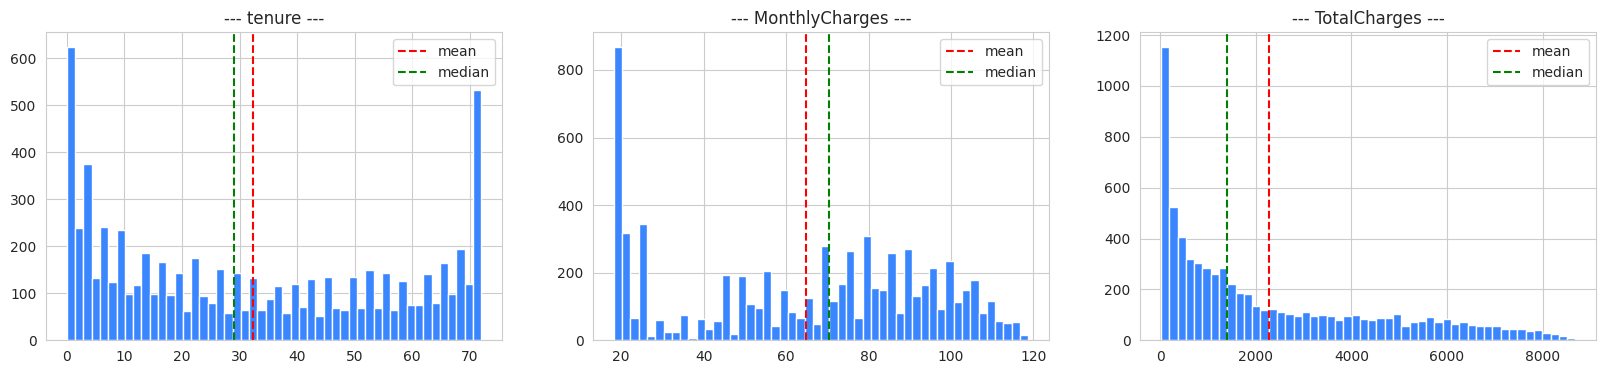

In [10]:
plt.figure(figsize=(20, 4))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'--- {col} ---')
    plt.legend()
    
plt.show()

In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


## FEATURE ENGINEERING

In [12]:
## -- FLAG EQUAL MONTH & TOTAL --
for df in [train, test, orig]:
    df['_EQUAL_Monthly_Total'] = (df['TotalCharges'] == df['MonthlyCharges']).astype(int)

train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,_EQUAL_Monthly_Total
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1,0
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1,1


In [13]:
# ## -- EXTRA ARITHMETIC FEATURES BASED ON CATEGORIES --
# def zero_bounded_cumsum(values):
#     cumsum = 0
#     result = []
#     for i in values:
#         if cumsum + i < 0:
#             cumsum = 0
#         else:
#             cumsum += i
#         result.append(cumsum)
#     return result

# TOP_CATS = ['Contract'] #, 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

# BOUNDS = []
# for cat in TOP_CATS:
#     print(f"-> GroupBy: {cat} ", end='\n')
#     for num in NUMS[1:]:
#         print(f"with {num}... ")
#         new_col = f"{cat[:5]}_CM_{num[:5]}"
#         train[new_col] = train.groupby(cat)[num].transform(zero_bounded_cumsum)
#         test[new_col] = test.groupby(cat)[num].transform(zero_bounded_cumsum)
#         orig[new_col] = orig.groupby(cat)[num].transform(zero_bounded_cumsum)
#         BOUNDS.append(new_col)

# print(f'☑️ ROLLING FEATURES CREATED: {BOUNDS}')

In [14]:
## -- Arithmetic interaction --
for df in [train, test, orig]:
    df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
    df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
    df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
              '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

train[arithmetic].head()

,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq
0,0.036339,57.029308,1.053844,27.518303,841.0
1,0.018395,65.141380,1.066910,54.362591,3364.0
2,0.017188,100.712929,0.996893,58.180775,3364.0
3,0.985856,70.699928,0.985857,1.014347,1.0
4,1.000000,70.449928,1.000001,1.000000,1.0


In [15]:
## -- Cyclic encoding --
for df in [train, test, orig]:
    for p in [12, 30]:
        df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
        df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [16]:
## -- FREQUENCY ENCODING --
NUMS_FREQ = []
print(f"\nCREATING FREQUENCIES... ", end='')
for col in NUMS:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    n = f'{col}_FREQ'
    print(n+', ', end='')
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    NUMS_FREQ.append(n)

print()
print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")


CREATING FREQUENCIES... tenure_FREQ, MonthlyCharges_FREQ, TotalCharges_FREQ, 
✅ TOTAL FREQUENCY FEEATURES: 3


In [17]:
INTER = []
TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_CATS, 3)), desc='Triplewise'):
    n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
    test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
    INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='One-To-Many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

# print(f"TOTAL INTERACTION FEATURES: {len(INTER)}")

Pairwise:   0%|          | 0/120 [00:00<?, ?it/s]

Triplewise:   0%|          | 0/20 [00:00<?, ?it/s]

In [18]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [20]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [21]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features = BASE, #+NUMS_FREQ, # 
    target = TARGET,
    aggs = ['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
    # fill_nan=True,
)

train, test, _, ORIG_COLS_2 = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features = NUMS,
    target = TARGET,
    aggs = ['skew', 'nunique', 'count', 'max', 'min'], # mean, median, count, std, skew, nunique, max, min
    # fill_nan=True,
)

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

TE_merging:   0%|          | 0/3 [00:00<?, ?it/s]

In [22]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 225


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,_EQUAL_Monthly_Total,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,tenure_FREQ,MonthlyCharges_FREQ,TotalCharges_FREQ,Bi_gender-|-SeniorCitizen,Bi_gender-|-Partner,Bi_gender-|-Dependents,Bi_gender-|-PhoneService,Bi_gender-|-MultipleLines,Bi_gender-|-InternetService,Bi_gender-|-OnlineSecurity,Bi_gender-|-OnlineBackup,Bi_gender-|-DeviceProtection,Bi_gender-|-TechSupport,Bi_gender-|-StreamingTV,Bi_gender-|-StreamingMovies,Bi_gender-|-Contract,Bi_gender-|-PaperlessBilling,Bi_gender-|-PaymentMethod,Bi_SeniorCitizen-|-Partner,Bi_SeniorCitizen-|-Dependents,Bi_SeniorCitizen-|-PhoneService,Bi_SeniorCitizen-|-MultipleLines,Bi_SeniorCitizen-|-InternetService,Bi_SeniorCitizen-|-OnlineSecurity,Bi_SeniorCitizen-|-OnlineBackup,Bi_SeniorCitizen-|-DeviceProtection,Bi_SeniorCitizen-|-TechSupport,Bi_SeniorCitizen-|-StreamingTV,Bi_SeniorCitizen-|-StreamingMovies,Bi_SeniorCitizen-|-Contract,Bi_SeniorCitizen-|-PaperlessBilling,Bi_SeniorCitizen-|-PaymentMethod,Bi_Partner-|-Dependents,Bi_Partner-|-PhoneService,Bi_Partner-|-MultipleLines,Bi_Partner-|-InternetService,Bi_Partner-|-OnlineSecurity,Bi_Partner-|-OnlineBackup,Bi_Partner-|-DeviceProtection,Bi_Partner-|-TechSupport,Bi_Partner-|-StreamingTV,Bi_Partner-|-StreamingMovies,Bi_Partner-|-Contract,Bi_Partner-|-PaperlessBilling,Bi_Partner-|-PaymentMethod,Bi_Dependents-|-PhoneService,Bi_Dependents-|-MultipleLines,Bi_Dependents-|-InternetService,Bi_Dependents-|-OnlineSecurity,Bi_Dependents-|-OnlineBackup,Bi_Dependents-|-DeviceProtection,Bi_Dependents-|-TechSupport,Bi_Dependents-|-StreamingTV,Bi_Dependents-|-StreamingMovies,Bi_Dependents-|-Contract,Bi_Dependents-|-PaperlessBilling,Bi_Dependents-|-PaymentMethod,Bi_PhoneService-|-MultipleLines,Bi_PhoneService-|-InternetService,Bi_PhoneService-|-OnlineSecurity,Bi_PhoneService-|-OnlineBackup,Bi_PhoneService-|-DeviceProtection,Bi_PhoneService-|-TechSupport,Bi_PhoneService-|-StreamingTV,Bi_PhoneService-|-StreamingMovies,Bi_PhoneService-|-Contract,Bi_PhoneService-|-PaperlessBilling,Bi_PhoneService-|-PaymentMethod,Bi_MultipleLines-|-InternetService,Bi_MultipleLines-|-OnlineSecurity,Bi_MultipleLines-|-OnlineBackup,Bi_MultipleLines-|-DeviceProtection,Bi_MultipleLines-|-TechSupport,Bi_MultipleLines-|-StreamingTV,Bi_MultipleLines-|-StreamingMovies,Bi_MultipleLines-|-Contract,Bi_MultipleLines-|-PaperlessBilling,Bi_MultipleLines-|-PaymentMethod,Bi_InternetService-|-OnlineSecurity,Bi_InternetService-|-OnlineBackup,Bi_InternetService-|-DeviceProtection,Bi_InternetService-|-TechSupport,Bi_InternetService-|-StreamingTV,Bi_InternetService-|-StreamingMovies,Bi_InternetService-|-Contract,Bi_InternetService-|-PaperlessBilling,Bi_InternetService-|-PaymentMethod,Bi_OnlineSecurity-|-OnlineBackup,Bi_OnlineSecurity-|-DeviceProtection,Bi_OnlineSecurity-|-TechSupport,Bi_OnlineSecurity-|-StreamingTV,Bi_OnlineSecurity-|-StreamingMovies,Bi_OnlineSecurity-|-Contract,Bi_OnlineSecurity-|-PaperlessBilling,Bi_OnlineSecurity-|-PaymentMethod,Bi_OnlineBackup-|-DeviceProtection,Bi_OnlineBackup-|-TechSupport,Bi_OnlineBackup-|-StreamingTV,Bi_OnlineBackup-|-StreamingMovies,Bi_OnlineBackup-|-Contract,Bi_OnlineBackup-|-PaperlessBilling,Bi_OnlineBackup-|-PaymentMethod,Bi_DeviceProtection-|-TechSupport,Bi_DeviceProtection-|-StreamingTV,Bi_DeviceProtection-|-StreamingMovies,Bi_DeviceProtection-|-Contract,Bi_DeviceProtection-|-PaperlessBilling,Bi_DeviceProtection-|-PaymentMethod,Bi_TechSupport-|-StreamingTV,Bi_TechSupport-|-StreamingMovies,Bi_TechSupport-|-Contract,Bi_TechSupport-|-PaperlessBilling,Bi_TechSupport-|-PaymentMethod,Bi_StreamingTV-|-StreamingMovies,Bi_StreamingTV-|-Contract,Bi_StreamingTV-|

# ML TRAINING

In [23]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):
    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")

    start = time()

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n ***** FOLD {idx + 1}/{kf.n_splits} | ", end='')

        ## -- Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # cme_features = ROUNDS
        # cme_cols = []

        # print(f"CategoryMeanEncoding: {len(cme_features)} | ", end='')
        # for c in cme_features:
        #     # n = f"CME_{c}"
        #     cme = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[c] = cme.fit_transform(X_train[[c]], y_train).fillna(-1)
        #     X_val[c]   = cme.transform(X_val[[c]]).fillna(-1)
        #     X_test[c]  = cme.transform(X_test[[c]]).fillna(-1)
        #     cme_cols.append(c)

        # ## -- TE Opt1. -> Using CUSTOM --
        # TE_1 = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        # X_train = TE_1.fit_transform(X_train, y_train)
        # X_val   = TE_1.transform(X_val)
        # X_test  = TE_1.transform(X_test)

        TE = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, y_train)
        X_val   = TE.transform(X_val)
        X_test  = TE.transform(X_test)

        combined = pd.concat([X_train, X_val, X_test])
        for c in cats:
            combined[c] = combined[c].astype(str).astype('category')

        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        print(f"Train shape: {X_train.shape} *****")

        dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
        dval   = xgb.DMatrix(X_val, y_val, enable_categorical=True)
        dtest  = xgb.DMatrix(X_test, enable_categorical=True)

        model = xgb.train( 
            params,
            dtrain,
            num_boost_round = 50_000,
            evals = [(dtrain, "train"), (dval, "valid")],
            early_stopping_rounds = 200,
            verbose_eval = 1000,
        )

        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, iteration_range=(0, model.best_iteration+1)).ravel()
        test_preds += model.predict(dtest, iteration_range=(0, model.best_iteration+1)).ravel()

        # Calculate and print fold score
        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'{YELLOW} • FOLD {idx+1} AUC: {fold_auc:.5f}{RESET}')

        ## -- Clean up memory -- X_val,
        del X_train, y_train, y_val, X_test, dtrain, dval, dtest
        gc.collect()

    # Average the test predictions
    test_preds /= kf.n_splits

    # Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • FOLD {i+1} AUC: {score:.5f}")

    # Calculate and print the final out-of-fold AUC
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
        'val_data': X_val,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [24]:
version_name = 'xgb2v2_'

all_model_predictions = {}

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [25]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = 'Trial_'
# COMPILER = []

# # for i, loop in enumerate(OUTER_LOOP):
# #     print(f">>>>>>>>>> ℹ️ MODEL {i+1}/{len(OUTER_LOOP)}")
# #     PARAMS = {
# #         # 'sampling_method': 'gradient_based',
# #         # # ----------------------------------
# #         # 'grow_policy': 'lossguide',
# #         # 'max_leaves': LEAVES,
# #         'max_depth': 4,
# #         # ------------------------------------
# #         'objective': 'binary:logistic',
# #         'eval_metric': 'auc',
# #         'learning_rate': 0.05,
# #         'subsample': 0.95,
# #         'colsample_bytree': 0.4,
# #         'reg_lambda': 3.0,
# #         'reg_alpha': 1.0,
# #         'min_child_weight': 2,
# #         'random_state': SEED,
# #         'verbosity': 0,
# #         'n_jobs': os.cpu_count(),
# #         'device': 'cuda' if torch.cuda.is_available() else 'cpu',
# #     }

# #     n = M_NAME + str(loop)
# #     all_model_predictions[n] = Trainer_CV(
# #         model_name=n,
# #         params=PARAMS,
# #         train_df=train,
# #         test_df=test,
# #         features=FEATURES,
# #         target=TARGET,
# #         kf=kf,
# #         cats=CATS,
# #     )

# #     COMPILER.append(all_model_predictions)

# OUT_LOOP = [1.0]
# INN_LOOP = [3.0]
# p_name   = ['l2', 'l1']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             'sampling_method': 'gradient_based',
#             # # ----------------------------------
#             # 'grow_policy': 'lossguide',
#             # 'max_leaves': 64,
#             # 'max_depth': outer,
#             # ------------------------------------
#             'objective': 'binary:logistic',
#             'eval_metric': 'auc',
#             'learning_rate': 0.05,
#             'subsample': 0.9,
#             'colsample_bytree': 0.2,
#             'reg_lambda': 1.0,
#             'reg_alpha': 3.0,
#             # 'min_child_weight': inner,
#             'random_state': SEED,
#             'verbosity': 0,
#             'n_jobs': os.cpu_count(),
#             'device': 'cuda' if torch.cuda.is_available() else 'cpu',
#         }
    
#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=CATS+DIGITS, #+['cat_tenure'],
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} model(s) ======\n")

In [26]:
# ==================================================
# Cross-Validation Results for Trial_depth=5__l1=3.0
# ==================================================
#  • FOLD 1 AUC: 0.91866
#  • FOLD 2 AUC: 0.91935
#  • FOLD 3 AUC: 0.91873
#  • FOLD 4 AUC: 0.91987
#  • FOLD 5 AUC: 0.91709
# -------------------------------------------------|
# Overall AUC: 0.918732
# Average AUC: 0.918739 ± 0.000934
# -------------------------------------------------|
# 2.81 mins

In [27]:
# -------------------------------------------------|
# Overall AUC: 0.919027
# Average AUC: 0.919033 ± 0.000881
# -------------------------------------------------|
# 5.30 mins

In [28]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))

# sns.lineplot(all_model_scores, marker='o')
# plt.title('XGBoost Scores', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score+5e-7, score, ha='center', va='baseline')

# plt.tick_params('x', rotation=45)
# plt.show()

In [29]:
## ======= BOOSTING =========
M_NAME = f"{version_name}gbt_"
LR = 0.005
DEPTH = 6
MIN_WEIGHT = 1
L1 = 1.0
L2 = 3.0

PARAMS = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': DEPTH,
    'learning_rate': LR,
    'subsample': 0.9,
    'colsample_bytree': 0.2,
    'reg_lambda': L2,
    'reg_alpha': L1,
    'min_child_weight': MIN_WEIGHT,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = M_NAME + str(LR).split('.')[1]
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=CATS+['_EQUAL_Monthly_Total'],
)

# for value in [3, 4]:
#     PARAMS['max_depth'] = value
#     n = M_NAME + str(value)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=CATS,
#     )


==================== Starting Cross-Validation for xgb2v2_gbt_005 ====================

 ***** FOLD 1/10 | Train shape: (534774, 225) *****
[0]	train-auc:0.90656	valid-auc:0.90555
[1000]	train-auc:0.91628	valid-auc:0.91442
[2000]	train-auc:0.91901	valid-auc:0.91572
[3000]	train-auc:0.92095	valid-auc:0.91629
[4000]	train-auc:0.92260	valid-auc:0.91658
[5000]	train-auc:0.92411	valid-auc:0.91673
[6000]	train-auc:0.92552	valid-auc:0.91686
[7000]	train-auc:0.92689	valid-auc:0.91694
[8000]	train-auc:0.92821	valid-auc:0.91701
[8472]	train-auc:0.92879	valid-auc:0.91701
 • FOLD 1 AUC: 0.91701

 ***** FOLD 2/10 | Train shape: (534774, 225) *****
[0]	train-auc:0.90688	valid-auc:0.90543
[1000]	train-auc:0.91629	valid-auc:0.91434
[2000]	train-auc:0.91904	valid-auc:0.91555
[3000]	train-auc:0.92099	valid-auc:0.91602
[4000]	train-auc:0.92265	valid-auc:0.91623
[5000]	train-auc:0.92418	valid-auc:0.91634
[6000]	train-auc:0.92562	valid-auc:0.91640
[7000]	train-auc:0.92698	valid-auc:0.91644
[8000]	train-au

In [30]:
## ======= LOSS GUIDE =========
M_NAME = f"{version_name}loss_"
LEAVES = 256

PARAMS = {
    # ----------------------------------
    'grow_policy': 'lossguide',
    'max_leaves': LEAVES,
    'max_depth': 0,
    # ----------------------------------
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'learning_rate': LR,
    'subsample': 0.9,
    'colsample_bytree': 0.2,
    'reg_alpha': L1,
    'reg_lambda': L2,
    'min_child_weight': MIN_WEIGHT,
    'random_state': SEED,
    'verbosity': 0,
    'n_jobs': os.cpu_count(),
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

n = M_NAME + str(LR).split('.')[1]
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=CATS+['_EQUAL_Monthly_Total'],
)

# for value in [3, 4]:
#     PARAMS['max_depth'] = value
#     n = M_NAME + str(value)
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=CATS,
#     )


==================== Starting Cross-Validation for xgb2v2_loss_005 ====================

 ***** FOLD 1/10 | Train shape: (534774, 225) *****
[0]	train-auc:0.91177	valid-auc:0.90992
[1000]	train-auc:0.92490	valid-auc:0.91596
[2000]	train-auc:0.93315	valid-auc:0.91682
[3000]	train-auc:0.93944	valid-auc:0.91696
[3217]	train-auc:0.94069	valid-auc:0.91696
 • FOLD 1 AUC: 0.91696

 ***** FOLD 2/10 | Train shape: (534774, 225) *****
[0]	train-auc:0.91195	valid-auc:0.90957
[1000]	train-auc:0.92498	valid-auc:0.91570
[2000]	train-auc:0.93322	valid-auc:0.91636
[2485]	train-auc:0.93640	valid-auc:0.91640
 • FOLD 2 AUC: 0.91641

 ***** FOLD 3/10 | Train shape: (534774, 225) *****
[0]	train-auc:0.91147	valid-auc:0.91179
[1000]	train-auc:0.92469	valid-auc:0.91784
[2000]	train-auc:0.93295	valid-auc:0.91856
[3000]	train-auc:0.93921	valid-auc:0.91869
[3656]	train-auc:0.94287	valid-auc:0.91871
 • FOLD 3 AUC: 0.91872

 ***** FOLD 4/10 | Train shape: (534774, 225) *****
[0]	train-auc:0.91176	valid-auc:0.909

In [31]:
# ## ======= GRADIENT-BASED =========
# M_NAME = f"{version_name}grad_"

# PARAMS = {
#     'sampling_method': 'gradient_based',
#     # ------------------------------------
#     'objective': 'binary:logistic',
#     'eval_metric': 'auc',
#     'max_depth': DEPTH,
#     'learning_rate': LR,
#     'subsample': 0.9,
#     'colsample_bytree': 0.2,
#     'reg_alpha': L1,
#     'reg_lambda': L2,
#     'min_child_weight': MIN_WEIGHT,
#     'random_state': SEED,
#     'verbosity': 0,
#     'n_jobs': os.cpu_count(),
#     'device': 'cuda' if torch.cuda.is_available() else 'cpu',
# }

# n = M_NAME + str(LR).split('.')[1]
# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS+['_EQUAL_Monthly_Total'],
# )

# # for value in [3, 4]:
# #     PARAMS['max_depth'] = value
# #     n = M_NAME + str(value)
# #     all_model_predictions[n] = Trainer_CV(
# #         model_name=n,
# #         params=PARAMS,
# #         train_df=train,
# #         test_df=test,
# #         features=FEATURES,
# #         target=TARGET,
# #         kf=kf,
# #         cats=CATS,
# #     )

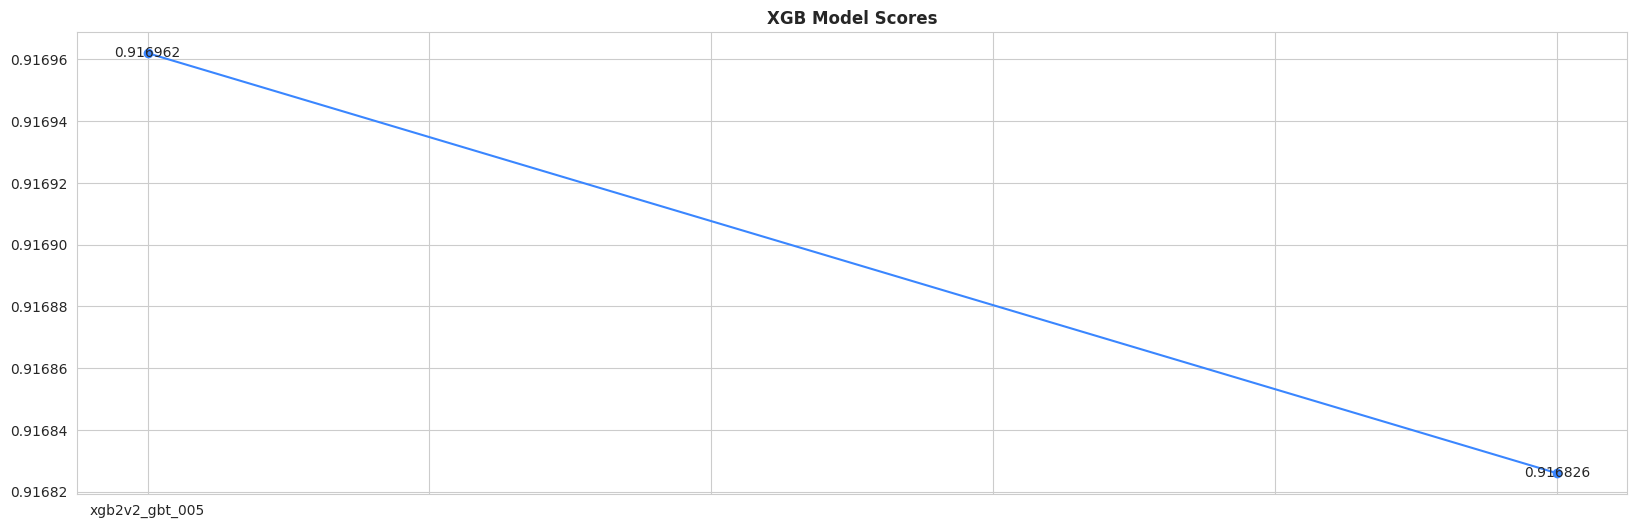

In [32]:
## -- Get Scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y


plt.figure(figsize=(20, 6))
pd.Series(all_model_scores).plot(marker='o')
plt.title('XGB Model Scores', fontweight='semibold')
for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+7e-7, score, ha='center', va='center_baseline')

plt.tick_params('x', rotation=0)
plt.show()

In [33]:
## -- Get oof outputs --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}_models.parquet", index=False)
all_model_oof.head()

,xgb2v2_gbt_005_916962,xgb2v2_loss_005_916826
0,0.010050,0.009633
1,0.000596,0.001102
2,0.295305,0.272569
3,0.733768,0.712932
4,0.814010,0.798778


In [34]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}_models.parquet", index=False)
all_model_test.head()

,xgb2v2_gbt_005_916962,xgb2v2_loss_005_916826
0,0.087721,0.079219
1,0.000533,0.000699
2,0.118472,0.124230
3,0.002430,0.002428
4,0.505169,0.487045


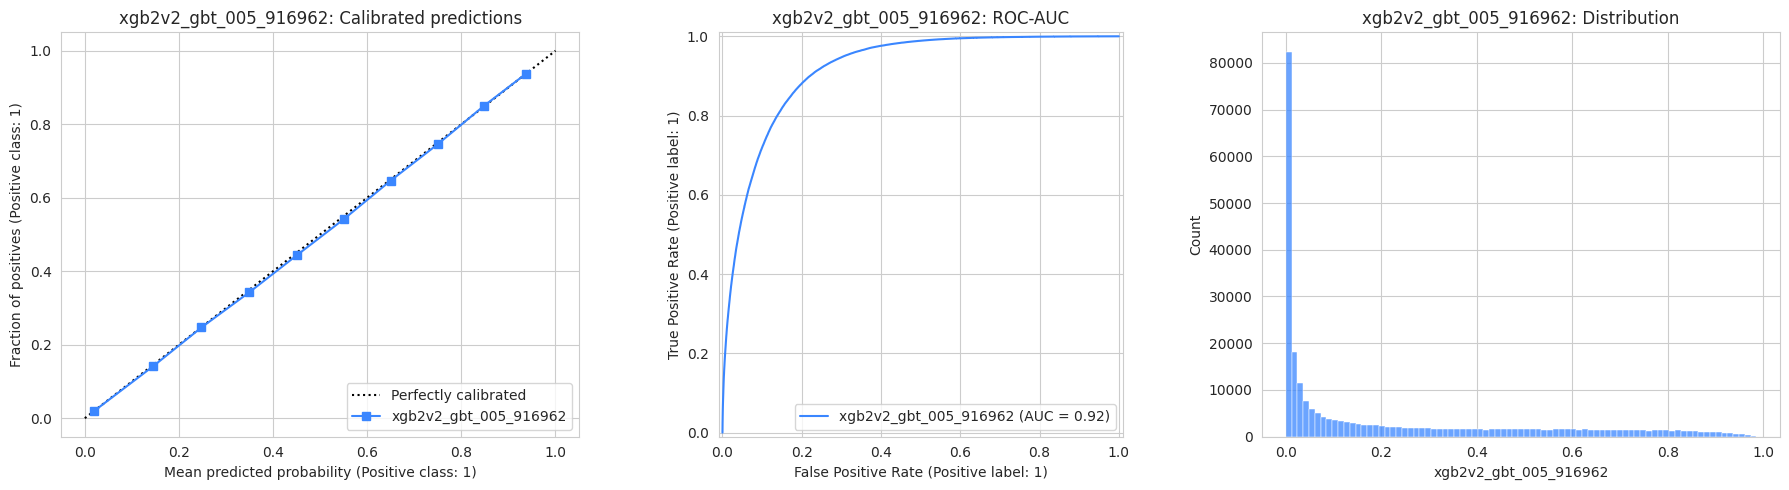

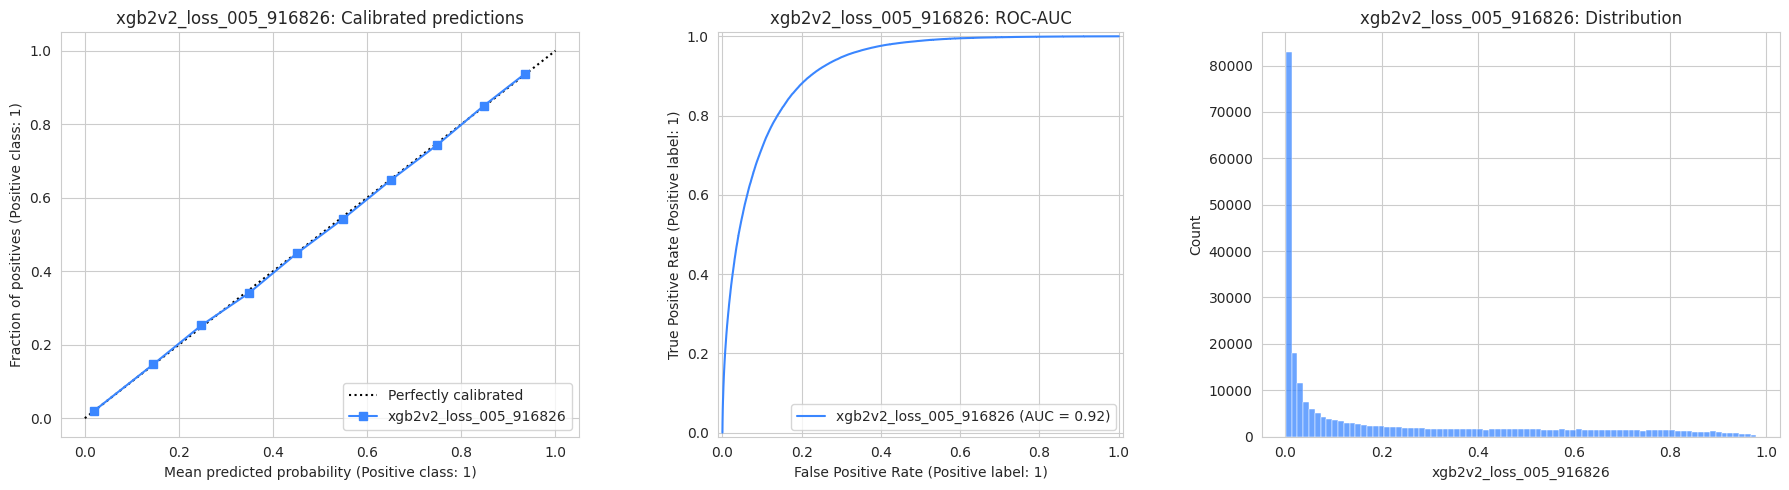

In [35]:
## -- PLOT MODEL PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    CalibrationDisplay.from_predictions(train[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibrated predictions")
    
    RocCurveDisplay.from_predictions(train[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")
    
    plt.tight_layout()
    plt.show()
    print()

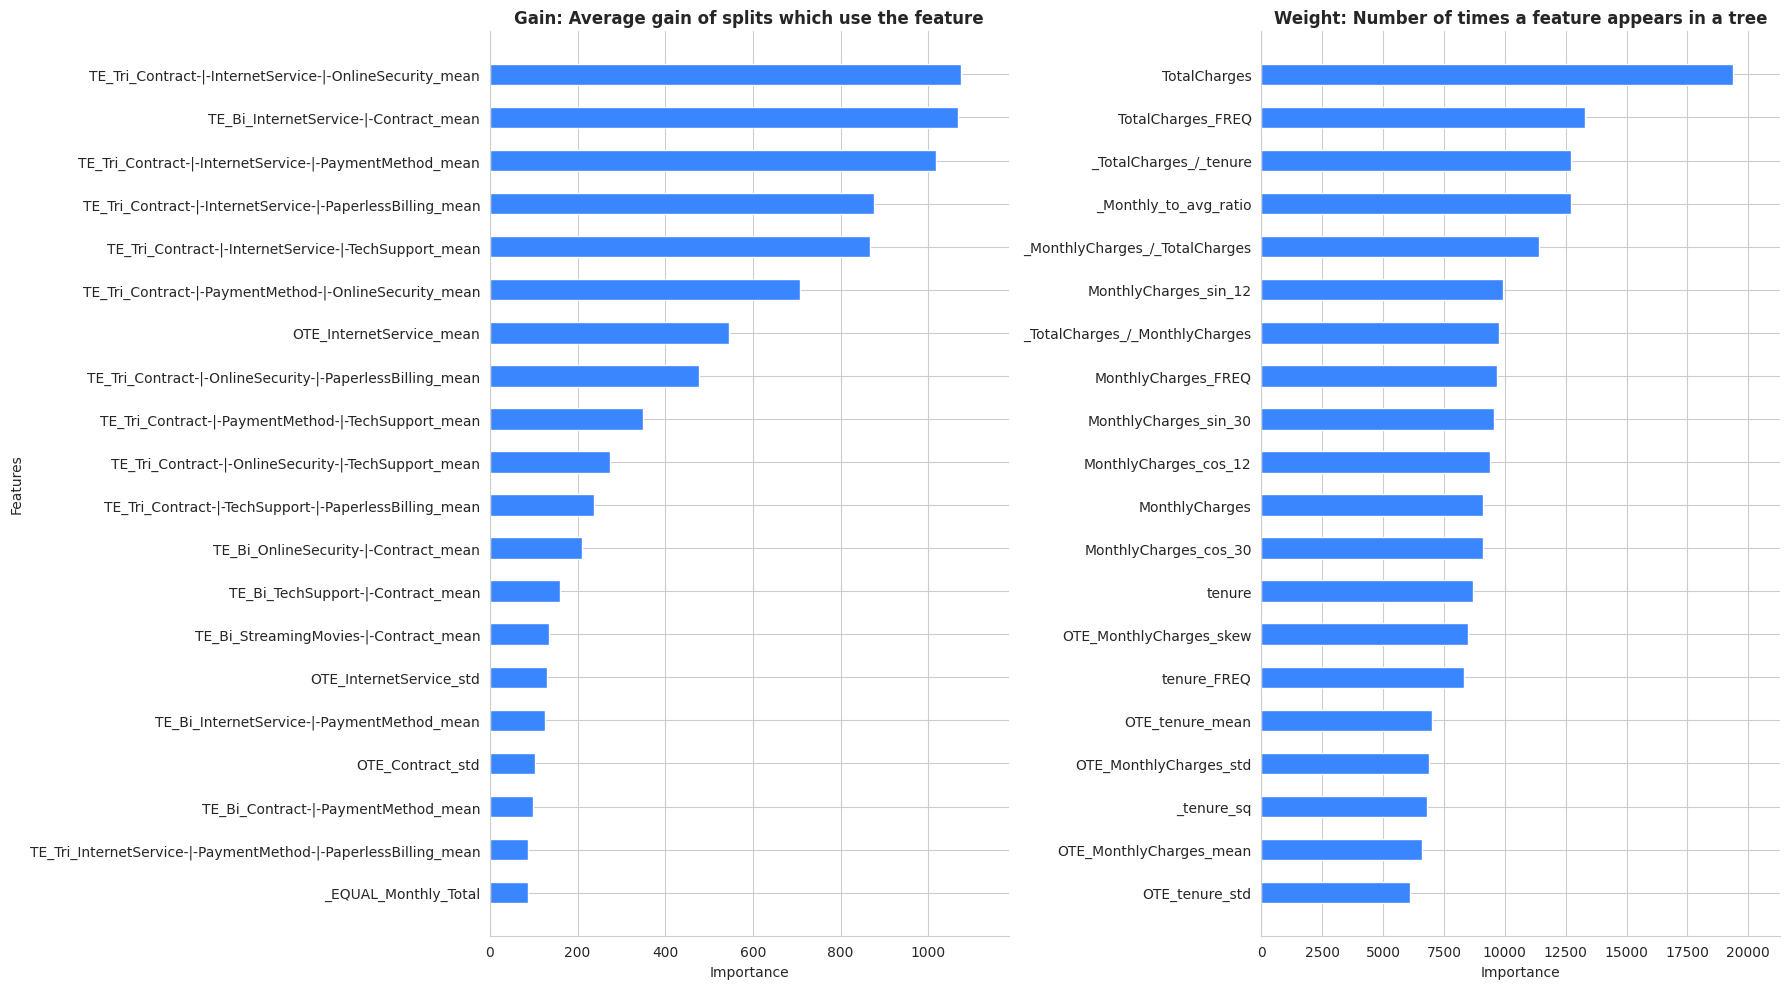

In [36]:
## -- Plot Feature Importances --
get_model = all_model_predictions[list(all_model_predictions.keys())[0]]

MAX = 20
_, axs = plt.subplots(1, 2, figsize=(18, 10))
xgb.plot_importance(
    get_model['model'],
    importance_type='gain',
    max_num_features=MAX,
    ax=axs[0], height=0.5, #grid=False,
    show_values=False,
)
axs[0].set_title('Gain: Average gain of splits which use the feature', fontweight='bold')

xgb.plot_importance(
    get_model['model'],
    importance_type='weight',
    max_num_features=MAX,
    ax=axs[1], height=0.5, #grid=False,
    show_values=False,
)
axs[1].set_title('Weight: Number of times a feature appears in a tree', fontweight='bold')
axs[1].set_ylabel('')

for ax in axs:
    ax.set_xlabel('Importance')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
plt.tight_layout()
plt.show()